In [25]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import requests
from io import StringIO

# Bygninger og Energiforbruk - Årlig oppløsning per byggeår

Henter data fra SSB for **2022**:
- **06266**: Antall eneboliger etter byggeår
- **10576**: Gjennomsnittlig energiforbruk per husholdning etter energibærer og byggeår

Splitter begge datasett til årlig oppløsning:
- **Antall boliger** (sum) → fordeles jevnt over årene i intervallet
- **Energiforbruk** (gjennomsnitt) → kopieres til hvert år i intervallet

In [26]:
# Hent antall eneboliger per byggeår fra SSB 06266
r = requests.get("https://data.ssb.no/api/pxwebapi/v2/tables/06266/data", params={
    'lang': 'no',
    'outputformat': 'csv',
    'valueCodes[Region]': '0',
    'valueCodes[BygnType]': '01',
    'valueCodes[BygnAr]': '*',
    'valueCodes[ContentsCode]': 'Boliger',
    'valueCodes[Tid]': '2022',
})
df_buildings = pd.read_csv(StringIO(r.text)).rename(columns={'Boliger 2022': 'Boliger'})
df_buildings

,Region,BygnType,BygnAr,Boliger
0,0,1,1,79505
1,0,1,2,48140
2,0,1,3,75266
3,0,1,4,8137
4,0,1,6,169835
5,0,1,7,158873
6,0,1,8,215772
7,0,1,9,195250
8,0,1,10,105851
9,0,1,11,93568


In [27]:
# Definer årsintervaller for 06266 byggeår-koder
bygn_year_ranges = {
    1:  (1900, 1900),  # 1900 og tidligere
    2:  (1901, 1920),
    3:  (1921, 1940),
    4:  (1941, 1945),
    6:  (1946, 1960),
    7:  (1961, 1970),
    8:  (1971, 1980),
    9:  (1981, 1990),
    10: (1991, 2000),
    11: (2001, 2010),
    12: (2011, 2020),
    13: (2021, 2022),
}

# Ekspansjontabell: BygnAr-kode → individuelle år + antall år i intervallet
expand_bygn = pd.DataFrame([
    {'BygnAr': code, 'year': y, 'n_years': end - start + 1}
    for code, (start, end) in bygn_year_ranges.items()
    for y in range(start, end + 1)
])

df_buildings_yearly = (
    df_buildings
    .merge(expand_bygn, on='BygnAr')
    .assign(antall_boliger=lambda d: d['Boliger'] / d['n_years'])
    [['year', 'antall_boliger']]
    .sort_values('year')
    .reset_index(drop=True)
)
print(f"{len(df_buildings_yearly)} årlige rader")
df_buildings_yearly

123 årlige rader


/Users/marcus/repositories/Beregninger_Scenariomodell/.venv/lib/python3.14/site-packages/pandas/core/frame.py:5246: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data[k] = com.apply_if_callable(v, data)


,year,antall_boliger
0,1900,79505.0
1,1901,2407.0
2,1902,2407.0
3,1903,2407.0
4,1904,2407.0
...,...,...
118,2018,7683.3
119,2019,7683.3
120,2020,7683.3
121,2021,3052.0


In [28]:
# Hent energiforbruk per husholdning fra SSB 10576
meta_energy = requests.get("https://data.ssb.no/api/pxwebapi/v2/tables/10576/metadata?lang=no")
energy_labels = meta_energy.json()['dimension']['Energibaerer']['category']['label']

r = requests.get("https://data.ssb.no/api/pxwebapi/v2/tables/10576/data", params={
    'lang': 'no',
    'outputformat': 'csv',
    'valueCodes[Energibaerer]': '*',
    'valueCodes[ByggeAar]': '*',
    'valueCodes[ContentsCode]': 'Forbruk',
    'valueCodes[Tid]': '2022',
})
df_energy = pd.read_csv(StringIO(r.text)).rename(columns={'Forbruk 2022': 'Forbruk'})
df_energy['Forbruk'] = pd.to_numeric(df_energy['Forbruk'], errors='coerce')
df_energy

/var/folders/z8/gvgsgtzj6wdg9x1hyg_5gbh80000gn/T/ipykernel_17808/2408266782.py:14: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_energy['Forbruk'] = pd.to_numeric(df_energy['Forbruk'], errors='coerce')


,Energibaerer,ByggeAar,Forbruk
0,0,30,17264.0
1,0,31,18110.0
2,0,51,17292.0
3,0,71,18737.0
4,0,81,20177.0
5,0,91,16498.0
6,0,92,14427.0
7,1.1,30,14385.0
8,1.1,31,14935.0
9,1.1,51,14642.0


In [29]:
# Definer årsintervaller for 10576 byggeår-koder
energy_year_ranges = {
    30: (1900, 1930),   # Før 1931
    31: (1931, 1954),
    51: (1955, 1970),
    71: (1971, 1986),
    81: (1987, 1996),
    91: (1997, 2009),
    92: (2010, 2022),
}

# Ekspansjontabell: ByggeAar-kode → individuelle år
expand_energy = pd.DataFrame([
    {'ByggeAar': code, 'year': y}
    for code, (start, end) in energy_year_ranges.items()
    for y in range(start, end + 1)
])

# Pivot energibærer → kolonner, deretter ekspander til årlig
df_energy_wide = (
    df_energy
    .pivot(index='ByggeAar', columns='Energibaerer', values='Forbruk')
    .rename(columns=energy_labels)
    .reset_index()
)

df_energy_yearly = (
    df_energy_wide
    .merge(expand_energy, on='ByggeAar')
    .drop(columns='ByggeAar')
    .sort_values('year')
    .reset_index(drop=True)
)
print(f"{len(df_energy_yearly)} årlige rader")
df_energy_yearly

123 årlige rader


,I alt,Elektrisitet,"Ved, pellets og vedbriketter",Olje og parafin,Gass og fjernvarme,year
0,17264.0,14385.0,2627.0,NaN,224.0,1900
1,17264.0,14385.0,2627.0,NaN,224.0,1901
2,17264.0,14385.0,2627.0,NaN,224.0,1902
3,17264.0,14385.0,2627.0,NaN,224.0,1903
4,17264.0,14385.0,2627.0,NaN,224.0,1904
...,...,...,...,...,...,...
118,14427.0,12559.0,882.0,NaN,948.0,2018
119,14427.0,12559.0,882.0,NaN,948.0,2019
120,14427.0,12559.0,882.0,NaN,948.0,2020
121,14427.0,12559.0,882.0,NaN,948.0,2021


In [30]:
# Merge bygningsdata og energidata på byggeår
df = (
    df_buildings_yearly
    .merge(df_energy_yearly, on='year', how='left')
    .sort_values('year')
    .reset_index(drop=True)
)
df

,year,antall_boliger,I alt,Elektrisitet,"Ved, pellets og vedbriketter",Olje og parafin,Gass og fjernvarme
0,1900,79505.0,17264.0,14385.0,2627.0,NaN,224.0
1,1901,2407.0,17264.0,14385.0,2627.0,NaN,224.0
2,1902,2407.0,17264.0,14385.0,2627.0,NaN,224.0
3,1903,2407.0,17264.0,14385.0,2627.0,NaN,224.0
4,1904,2407.0,17264.0,14385.0,2627.0,NaN,224.0
...,...,...,...,...,...,...,...
118,2018,7683.3,14427.0,12559.0,882.0,NaN,948.0
119,2019,7683.3,14427.0,12559.0,882.0,NaN,948.0
120,2020,7683.3,14427.0,12559.0,882.0,NaN,948.0
121,2021,3052.0,14427.0,12559.0,882.0,NaN,948.0


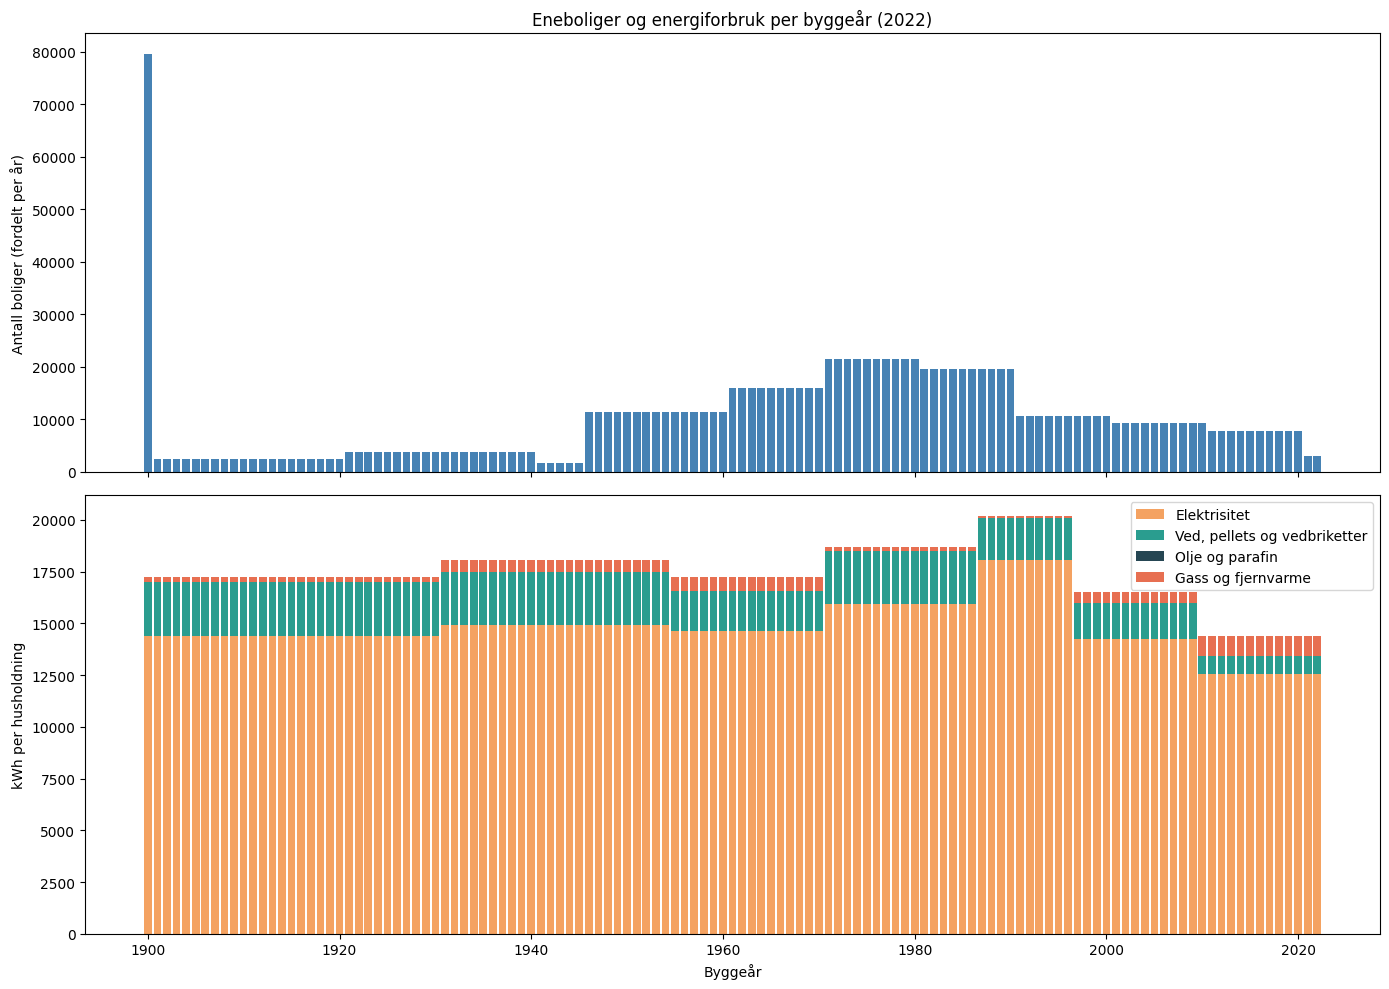

In [31]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

ax1.bar(df['year'], df['antall_boliger'], color='steelblue', width=0.8)
ax1.set_ylabel('Antall boliger (fordelt per år)')
ax1.set_title('Eneboliger og energiforbruk per byggeår (2022)')

energy_plot_cols = ['Elektrisitet', 'Ved, pellets og vedbriketter', 'Olje og parafin', 'Gass og fjernvarme']
colors = ['#f4a261', '#2a9d8f', '#264653', '#e76f51']
bottom = np.zeros(len(df))
for col, color in zip(energy_plot_cols, colors):
    vals = df[col].fillna(0).values
    ax2.bar(df['year'], vals, bottom=bottom, label=col, color=color, width=0.8)
    bottom += vals

ax2.set_xlabel('Byggeår')
ax2.set_ylabel('kWh per husholdning')
ax2.legend()

plt.tight_layout()
plt.show()

In [32]:
df

,year,antall_boliger,I alt,Elektrisitet,"Ved, pellets og vedbriketter",Olje og parafin,Gass og fjernvarme
0,1900,79505.0,17264.0,14385.0,2627.0,NaN,224.0
1,1901,2407.0,17264.0,14385.0,2627.0,NaN,224.0
2,1902,2407.0,17264.0,14385.0,2627.0,NaN,224.0
3,1903,2407.0,17264.0,14385.0,2627.0,NaN,224.0
4,1904,2407.0,17264.0,14385.0,2627.0,NaN,224.0
...,...,...,...,...,...,...,...
118,2018,7683.3,14427.0,12559.0,882.0,NaN,948.0
119,2019,7683.3,14427.0,12559.0,882.0,NaN,948.0
120,2020,7683.3,14427.0,12559.0,882.0,NaN,948.0
121,2021,3052.0,14427.0,12559.0,882.0,NaN,948.0


In [33]:
df.drop(columns='Olje og parafin').rename(columns={'year': 'byggeaar'}).to_csv('data/bygningsbestand_2022.csv', index=False)
df

,year,antall_boliger,I alt,Elektrisitet,"Ved, pellets og vedbriketter",Olje og parafin,Gass og fjernvarme
0,1900,79505.0,17264.0,14385.0,2627.0,NaN,224.0
1,1901,2407.0,17264.0,14385.0,2627.0,NaN,224.0
2,1902,2407.0,17264.0,14385.0,2627.0,NaN,224.0
3,1903,2407.0,17264.0,14385.0,2627.0,NaN,224.0
4,1904,2407.0,17264.0,14385.0,2627.0,NaN,224.0
...,...,...,...,...,...,...,...
118,2018,7683.3,14427.0,12559.0,882.0,NaN,948.0
119,2019,7683.3,14427.0,12559.0,882.0,NaN,948.0
120,2020,7683.3,14427.0,12559.0,882.0,NaN,948.0
121,2021,3052.0,14427.0,12559.0,882.0,NaN,948.0


In [34]:
carbon_intensities = { ### temporary guesses
    'Elektrisitet':                   0.250,   # Europe grid mix gCO2/kWh → kg
    'Olje og parafin':                0.267,   # Heating oil ~267 gCO2/kWh
    'Ved, pellets og vedbriketter':   0.0,     # Biogenic, typically counted as 0 in national accounts
    'Gass og fjernvarme':             0.130,   # Rough mix; district heating varies by source
}

energy_cols = list(carbon_intensities.keys())

for col in energy_cols:
    df[f'emissions_{col}'] = df['antall_boliger'] * df[col].fillna(0) * carbon_intensities[col]

emission_cols = [f'emissions_{col}' for col in energy_cols]
df['total_emissions_kg'] = df[emission_cols].sum(axis=1)

total_tco2 = df['total_emissions_kg'].sum() / 1e3
print(f"Total CO2 fra eneboliger (2022): {total_tco2:,.0f} tonn CO2")

Total CO2 fra eneboliger (2022): 4,747,425 tonn CO2


In [35]:
meta = requests.get("https://data.ssb.no/api/pxwebapi/v2/tables/06265/metadata?lang=no")
meta.json()

{'version': '2.0',
 'class': 'dataset',
 'label': '06265: Boliger, etter bygningstype (K) 2006-2025',
 'source': 'Statistisk sentralbyrå',
 'updated': '2025-03-04T07:00:00Z',
 'note': ['Populasjon: \nNye tall for  boligpopulasjon 2012, 2013, 2014, 2015 og 2016. Modell for avgrensing av boligpopulasjonen er noe endret, slik at det blir et brudd i statistikken før og etter 2012. Boligpopulasjonen avgrenses vha Matrikkelen og Folkeregisteret. Kjennemerkene som brukes er bygningstype, bygningsstatus, bruksenhetstype og hvorvidt det er registrert bosatte i bruksenhet eller bygning. Fritidsboliger og bruksenheter registrert som annet enn bolig inkluderes i statistikken dersom det ifølge folkeregisteret er registrert bosatte på boligens adresse.  Folkeregisteret brukes også til å overstyre informasjon, eksempelvis ved manglende ferdigattest, dersom det er registrert bosatte i bygningen. I tillegg imputeres boliger i boligbygninger med registrert bosatte men uten registrerte bruksenheter.',
  

In [36]:
meta = requests.get("https://data.ssb.no/api/pxwebapi/v2/tables/10576/metadata?lang=no")
meta.json()

{'version': '2.0',
 'class': 'dataset',
 'label': '10576: Gjennomsnittlig energiforbruk per husholdning, etter energibærer og byggeår 2009-2022',
 'source': 'Statistisk sentralbyrå',
 'updated': '2025-07-23T06:00:00Z',
 'note': ['For året 2012 er boliger bygget fra og med 2010 inkludert i 1997-2009.'],
 'role': {'time': ['Tid'], 'metric': ['ContentsCode']},
 'id': ['Energibaerer', 'ByggeAar', 'ContentsCode', 'Tid'],
 'size': [5, 7, 1, 3],
 'dimension': {'Energibaerer': {'label': 'energibærer',
   'category': {'index': {'0': 0, '1.1': 1, '3.0': 2, '2.01': 3, '4-5': 4},
    'label': {'0': 'I alt',
     '1.1': 'Elektrisitet',
     '3.0': 'Olje og parafin',
     '2.01': 'Ved, pellets og vedbriketter',
     '4-5': 'Gass og fjernvarme'}},
   'extension': {'elimination': True, 'show': 'value', 'codelists': []}},
  'ByggeAar': {'label': 'byggeår',
   'category': {'index': {'30': 0,
     '31': 1,
     '51': 2,
     '71': 3,
     '81': 4,
     '91': 5,
     '92': 6},
    'label': {'30': 'Før 193